# Diabetes Prediction - Improved NumPy Deep Learning

Notebook này là bản cải tiến từ baseline `diabetes_numpy_deep_learning.ipynb`.

Mục tiêu của notebook là giữ lại tinh thần học thuật của slide: tự xây neural network bằng NumPy, không dùng framework deep learning, đồng thời cải thiện một số điểm thường làm mô hình baseline yếu khi chạy trên dữ liệu diabetes thực tế.

Quy ước trong notebook:

- Mỗi code cell bắt đầu bằng phần `# --- BASELINE CODE (COMMENTED) ---`. Đây là code baseline cũ được giữ nguyên văn, chỉ thêm dấu `# ` ở đầu từng dòng để không chạy.
- Phần `# --- IMPROVED CODE ---` là code cải tiến được thực thi.
- Các giải thích trước từng cell nêu rõ mục đích, dữ liệu đầu vào, kết quả đầu ra và lý do cải tiến.

Các cải tiến chính:

- Validation split để theo dõi generalization.
- Impute các giá trị 0 bất thường trong Pima diabetes data bằng median của train set.
- Kiến trúc `8 -> 32 -> 16 -> 1`.
- Class-weighted binary cross-entropy.
- L2 regularization.
- Mini-batch gradient descent.
- Early stopping theo validation loss.
- Tune threshold trên validation set theo F1.
- Bổ sung các biểu đồ để quan sát dữ liệu, preprocessing, training và evaluation.

## 1. Load Data

Cell này nạp dữ liệu từ file `diabetes.csv`, đúng kiểu dữ liệu mà slide sử dụng. File có 9 cột: 8 cột đầu là đặc trưng đầu vào của bệnh nhân, cột cuối `Outcome` là nhãn cần dự đoán.

Baseline trong slide cũng dùng `np.loadtxt`, `skiprows=1`, sau đó tách `X = data[:, :8]` và `y = data[:, 8].reshape(-1, 1)`. Bản cải tiến vẫn giữ cách nạp này để đảm bảo kế thừa baseline, chỉ bổ sung thêm danh sách tên cột, kiểm tra shape của dữ liệu và in tỷ lệ lớp dương để hiểu mức mất cân bằng của dataset.

Kết quả sau cell này:

- `X`: ma trận đặc trưng có shape `(số_mẫu, 8)`.
- `y`: vector nhãn nhị phân có shape `(số_mẫu, 1)`.
- `FEATURE_NAMES`: tên 8 đặc trưng, dùng cho bước xử lý dữ liệu tiếp theo.

In [28]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # DEEP LEARNING FROM SCRATCH
# # Diabetes Prediction
# #
# # NO TensorFlow
# # NO PyTorch
# # NO Keras
# # NO Scikit-learn
# #
# # Only NumPy is used for the neural network.
# # ============================================================
# 
# from pathlib import Path
# import numpy as np
# 
# # ============================================================
# # 1. LOAD DATA
# # ============================================================
# 
# DATA_CANDIDATES = [
#     Path("../data/diabetes.csv"),
#     Path("data/diabetes.csv"),
#     Path("src/Assigment 03/diabetes/data/diabetes.csv"),
# ]
# 
# data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
# if data_path is None:
#     raise FileNotFoundError("Could not find diabetes.csv")
# 
# data = np.loadtxt(
#     data_path,
#     delimiter=",",
#     skiprows=1
# )
# 
# X = data[:, :8]
# y = data[:, 8].reshape(-1, 1)
# 
# print("Data path:", data_path.resolve())
# print("X shape:", X.shape)
# print("y shape:", y.shape)
# --- IMPROVED CODE ---

from pathlib import Path
import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

np.set_printoptions(precision=4, suppress=True)

FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET_NAME = "Outcome"

DATA_CANDIDATES = [
    Path("../data/diabetes.csv"),
    Path("data/diabetes.csv"),
    Path("src/Assigment 03/diabetes/data/diabetes.csv"),
]

data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find diabetes.csv")

data = np.loadtxt(
    data_path,
    delimiter=",",
    skiprows=1
)

if data.ndim != 2 or data.shape[1] != 9:
    raise ValueError(
        f"Expected diabetes.csv to have 9 columns: 8 features + 1 target. Got shape {data.shape}."
    )

X = data[:, :8].astype(float)
y = data[:, 8].reshape(-1, 1).astype(float)

print("Data path:", data_path.resolve())
print("Feature names:", FEATURE_NAMES)
print("Target name:", TARGET_NAME)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive class rate:", y.mean())

Data path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/data/diabetes.csv
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target name: Outcome
X shape: (768, 8)
y shape: (768, 1)
Positive class rate: 0.3489583333333333


In [29]:
# ============================================================
# FIGURE OUTPUT
# ============================================================

DATA_PATH = data_path.resolve()
FIGURE_DIR = DATA_PATH.parent.parent / "report" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename):
    if plt is None:
        return None
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


## 1.1. Visualize Raw Data

Cell này vẽ các biểu đồ tổng quan ngay sau khi load dữ liệu. Mục tiêu là nhìn nhanh dataset trước khi tiền xử lý và huấn luyện.

Các biểu đồ gồm: phân bố nhãn `Outcome`, số lượng giá trị 0 ở từng feature, và histogram của từng feature theo hai lớp `Outcome = 0` và `Outcome = 1`. Những hình này giúp thấy dataset có mất cân bằng lớp hay không, feature nào có nhiều giá trị 0 bất thường, và phân bố feature giữa hai nhóm bệnh nhân khác nhau thế nào.

Baseline không có phần visualization này, nên block baseline bên dưới chỉ ghi chú rằng đây là cell bổ sung.

Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/report/figures/diabetes_raw_outcome_zero_values.png


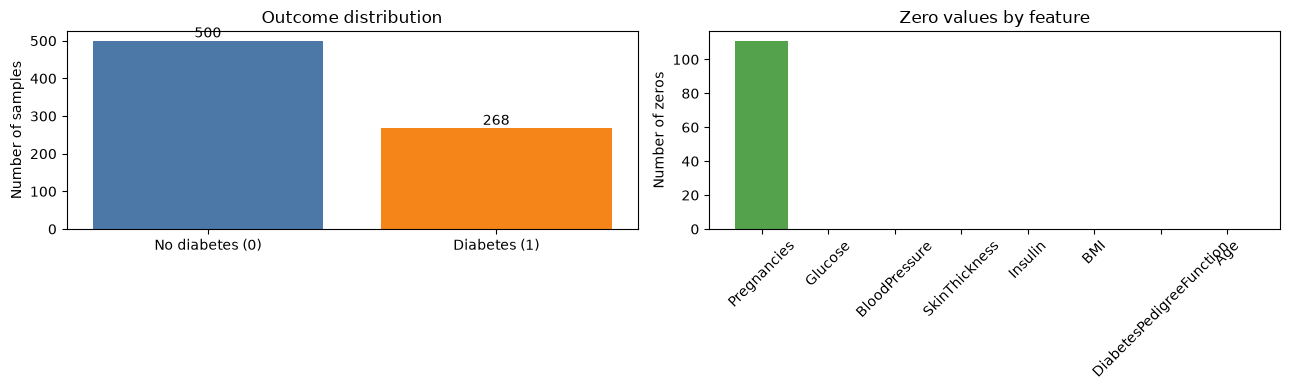

Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/report/figures/diabetes_raw_feature_distributions_by_outcome.png


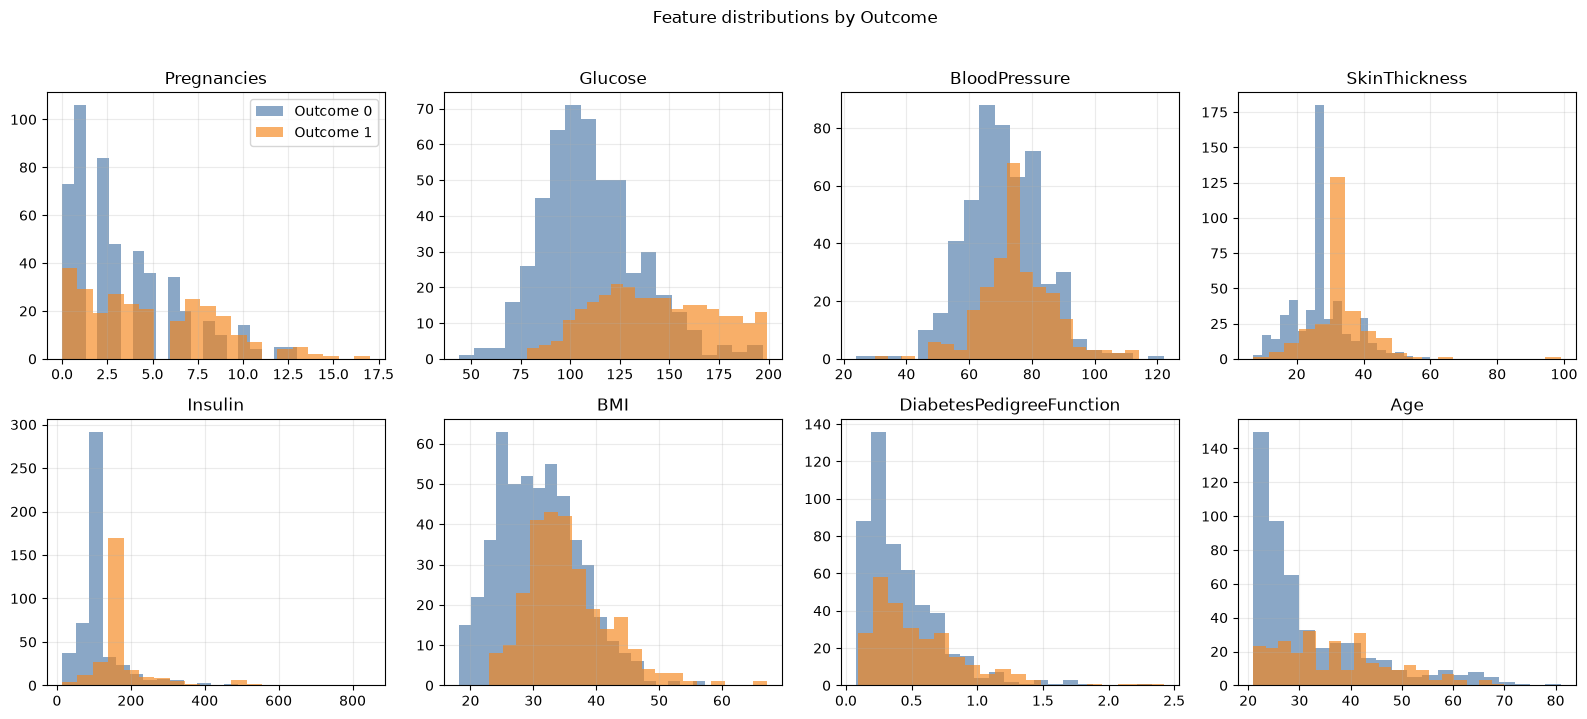

In [30]:
# --- BASELINE CODE (COMMENTED) ---
# Baseline notebook did not include raw data visualization.
# --- IMPROVED CODE ---

if plt is None:
    print("Matplotlib is not installed, so raw data charts are skipped.")
else:
    outcome_values = y.ravel().astype(int)
    class_counts = np.bincount(outcome_values, minlength=2)
    zero_counts = np.sum(X == 0, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(
        ["No diabetes (0)", "Diabetes (1)"],
        class_counts,
        color=["#4C78A8", "#F58518"],
    )
    axes[0].set_title("Outcome distribution")
    axes[0].set_ylabel("Number of samples")
    for idx, value in enumerate(class_counts):
        axes[0].text(idx, value, str(value), ha="center", va="bottom")

    axes[1].bar(FEATURE_NAMES, zero_counts, color="#54A24B")
    axes[1].set_title("Zero values by feature")
    axes[1].set_ylabel("Number of zeros")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    save_current_figure("diabetes_raw_outcome_zero_values.png")
    plt.show()

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for feature_idx, ax in enumerate(axes.ravel()):
        values_no_diabetes = X[outcome_values == 0, feature_idx]
        values_diabetes = X[outcome_values == 1, feature_idx]

        ax.hist(
            values_no_diabetes,
            bins=20,
            alpha=0.65,
            label="Outcome 0",
            color="#4C78A8",
        )
        ax.hist(
            values_diabetes,
            bins=20,
            alpha=0.65,
            label="Outcome 1",
            color="#F58518",
        )
        ax.set_title(FEATURE_NAMES[feature_idx])
        ax.grid(True, alpha=0.25)

    axes[0, 0].legend()
    fig.suptitle("Feature distributions by Outcome", y=1.02)
    plt.tight_layout()
    save_current_figure("diabetes_raw_feature_distributions_by_outcome.png")
    plt.show()


## 2. Train/Test/Validation Split

Cell này chia dữ liệu thành ba phần: training, validation và testing. Baseline chỉ chia 80% train và 20% test bằng `np.random.permutation`. Bản cải tiến vẫn giữ đúng split 80/20 ban đầu để không thay đổi tinh thần baseline, sau đó lấy thêm một phần trong training set làm validation set.

Validation set không dùng để cập nhật trọng số. Nó dùng để chọn thời điểm dừng huấn luyện và chọn threshold dự đoán tốt hơn. Cách này giúp giảm nguy cơ mô hình học quá sát training set nhưng đánh giá kém trên dữ liệu mới.

Kết quả sau cell này:

- `X_train_raw`, `y_train`: dữ liệu dùng để học trọng số.
- `X_valid_raw`, `y_valid`: dữ liệu dùng để theo dõi validation loss và tune threshold.
- `X_test_raw`, `y_test`: dữ liệu chỉ dùng cho đánh giá cuối cùng.

In [31]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 2. TRAIN / TEST SPLIT
# # ============================================================
# 
# np.random.seed(42)
# 
# indices = np.random.permutation(len(X))
# split = int(0.8 * len(X))
# 
# train_idx = indices[:split]
# test_idx = indices[split:]
# 
# X_train = X[train_idx]
# y_train = y[train_idx]
# 
# X_test = X[test_idx]
# y_test = y[test_idx]
# 
# print("Training samples:", len(X_train))
# print("Testing samples :", len(X_test))
# --- IMPROVED CODE ---

np.random.seed(42)

indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_full_idx = indices[:split]
test_idx = indices[split:]

X_train_full = X[train_full_idx]
y_train_full = y[train_full_idx]
X_test_raw = X[test_idx]
y_test = y[test_idx]

validation_ratio = 0.2
validation_split = int((1.0 - validation_ratio) * len(X_train_full))

X_train_raw = X_train_full[:validation_split]
y_train = y_train_full[:validation_split]
X_valid_raw = X_train_full[validation_split:]
y_valid = y_train_full[validation_split:]

print("Training samples  :", len(X_train_raw))
print("Validation samples:", len(X_valid_raw))
print("Testing samples   :", len(X_test_raw))
print("Train positive rate     :", y_train.mean())
print("Validation positive rate:", y_valid.mean())
print("Test positive rate      :", y_test.mean())

Training samples  : 491
Validation samples: 123
Testing samples   : 154
Train positive rate     : 0.35845213849287166
Validation positive rate: 0.2764227642276423
Test positive rate      : 0.37662337662337664


## 3. Preprocessing

Cell này xử lý dữ liệu trước khi đưa vào neural network. Baseline chỉ normalize trực tiếp bằng mean và standard deviation của `X_train`. Bản cải tiến thêm một bước quan trọng cho Pima diabetes dataset: thay các giá trị `0` bất thường ở một số cột y tế bằng median tính từ training set.

Các cột như `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` thường không hợp lý nếu bằng 0 về mặt y khoa. Nếu giữ nguyên, mô hình có thể học từ nhiễu dữ liệu thay vì tín hiệu thật. Median được tính chỉ từ train set để tránh data leakage sang validation/test.

Sau imputation, cell normalize cả train, validation và test bằng `mean`/`std` của train set. Đây là nguyên tắc quan trọng: mọi thống kê tiền xử lý phải học từ train set, rồi áp dụng lại cho các tập còn lại.

Kết quả sau cell này:

- `X_train`, `X_valid`, `X_test`: dữ liệu đã impute và normalize.
- `zero_imputation_medians`: median dùng để thay giá trị 0 bất thường.
- `mean`, `std`: thống kê normalize học từ training set.

In [32]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 3. NORMALIZATION
# # ============================================================
# 
# mean = X_train.mean(axis=0)
# std = X_train.std(axis=0) + 1e-8
# 
# X_train = (X_train - mean) / std
# X_test = (X_test - mean) / std
# --- IMPROVED CODE ---

ZERO_AS_MISSING_FEATURES = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]
ZERO_AS_MISSING_INDICES = [FEATURE_NAMES.index(name) for name in ZERO_AS_MISSING_FEATURES]


def fit_zero_imputation_medians(X_train_raw):
    medians = {}
    for idx in ZERO_AS_MISSING_INDICES:
        non_zero_values = X_train_raw[X_train_raw[:, idx] != 0, idx]
        if len(non_zero_values) == 0:
            medians[idx] = 0.0
        else:
            medians[idx] = float(np.median(non_zero_values))
    return medians


def apply_zero_imputation(X_raw, medians):
    X_imputed = X_raw.copy()
    for idx, median in medians.items():
        zero_mask = X_imputed[:, idx] == 0
        X_imputed[zero_mask, idx] = median
    return X_imputed


zero_imputation_medians = fit_zero_imputation_medians(X_train_raw)

X_train_imputed = apply_zero_imputation(X_train_raw, zero_imputation_medians)
X_valid_imputed = apply_zero_imputation(X_valid_raw, zero_imputation_medians)
X_test_imputed = apply_zero_imputation(X_test_raw, zero_imputation_medians)

mean = X_train_imputed.mean(axis=0)
std = X_train_imputed.std(axis=0) + 1e-8

X_train = (X_train_imputed - mean) / std
X_valid = (X_valid_imputed - mean) / std
X_test = (X_test_imputed - mean) / std

print("Zero-imputation medians:")
for idx, median in zero_imputation_medians.items():
    print(f"{FEATURE_NAMES[idx]:24s}: {median:.4f}")
print("Train normalized mean:", X_train.mean(axis=0))
print("Train normalized std :", X_train.std(axis=0))

Zero-imputation medians:
Glucose                 : 117.0000
BloodPressure           : 72.0000
SkinThickness           : 28.0000
Insulin                 : 102.5000
BMI                     : 32.4000
Train normalized mean: [-0.  0. -0.  0.  0. -0.  0. -0.]
Train normalized std : [1. 1. 1. 1. 1. 1. 1. 1.]


## 3.1. Visualize Preprocessing Effect

Cell này kiểm tra trực quan xem bước preprocessing đã làm gì với dữ liệu. Biểu đồ đầu tiên so sánh số lượng giá trị 0 bất thường trước và sau khi impute median trên training set.

Biểu đồ thứ hai là boxplot của các feature sau normalization. Nếu normalization hoạt động đúng, các feature sẽ được đưa về cùng thang đo, giúp neural network học ổn định hơn và tránh feature có giá trị lớn lấn át các feature còn lại.

Baseline chỉ normalize dữ liệu và không vẽ biểu đồ kiểm tra, nên cell này là phần bổ sung để quan sát chất lượng preprocessing.

Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/report/figures/diabetes_preprocessing_effect.png


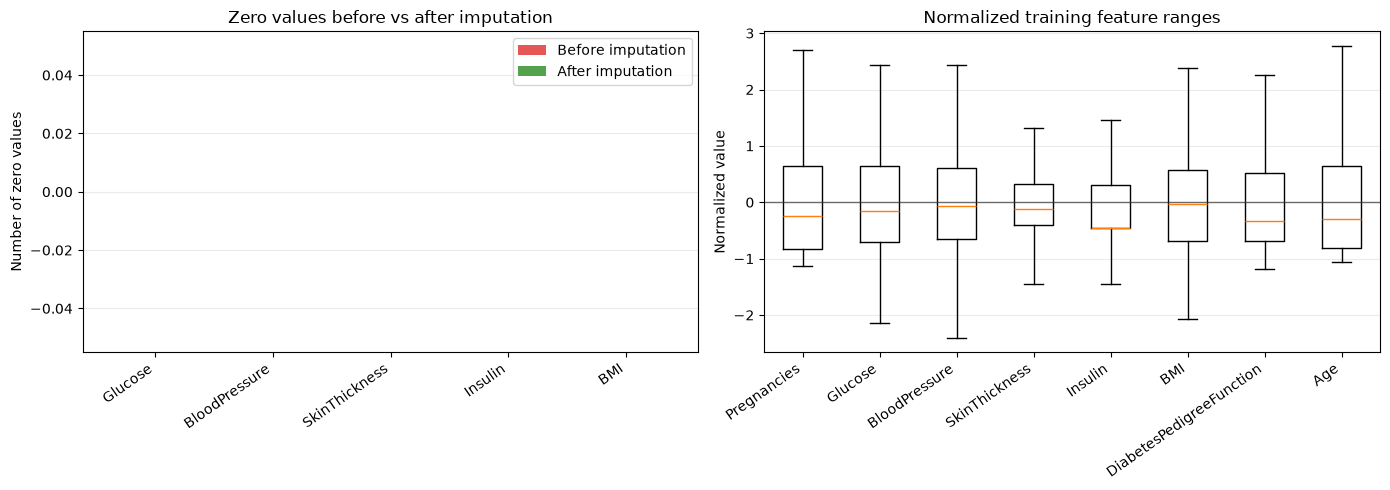

In [33]:
# --- BASELINE CODE (COMMENTED) ---
# Baseline notebook did not include preprocessing visualization.
# --- IMPROVED CODE ---

if plt is None:
    print("Matplotlib is not installed, so preprocessing charts are skipped.")
else:
    zero_counts_before = np.sum(
        X_train_raw[:, ZERO_AS_MISSING_INDICES] == 0,
        axis=0,
    )
    zero_counts_after = np.sum(
        X_train_imputed[:, ZERO_AS_MISSING_INDICES] == 0,
        axis=0,
    )
    zero_feature_names = [FEATURE_NAMES[idx] for idx in ZERO_AS_MISSING_INDICES]
    x_positions = np.arange(len(zero_feature_names))
    width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(
        x_positions - width / 2,
        zero_counts_before,
        width,
        label="Before imputation",
        color="#E45756",
    )
    axes[0].bar(
        x_positions + width / 2,
        zero_counts_after,
        width,
        label="After imputation",
        color="#54A24B",
    )
    axes[0].set_title("Zero values before vs after imputation")
    axes[0].set_ylabel("Number of zero values")
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(zero_feature_names, rotation=35, ha="right")
    axes[0].legend()
    axes[0].grid(True, axis="y", alpha=0.25)

    axes[1].boxplot(
        [X_train[:, idx] for idx in range(X_train.shape[1])],
        showfliers=False,
    )
    axes[1].set_title("Normalized training feature ranges")
    axes[1].set_ylabel("Normalized value")
    axes[1].set_xticks(np.arange(1, len(FEATURE_NAMES) + 1))
    axes[1].set_xticklabels(FEATURE_NAMES, rotation=35, ha="right")
    axes[1].axhline(0, color="#333333", linewidth=1, alpha=0.7)
    axes[1].grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    save_current_figure("diabetes_preprocessing_effect.png")
    plt.show()


## 4. Activation Functions

Cell này định nghĩa các hàm activation dùng trong mạng neural network. Phần này giữ gần như nguyên vẹn baseline vì đây là lõi toán học trong slide.

`ReLU` được dùng ở hidden layers để đưa phi tuyến vào mô hình. Nếu chỉ xếp nhiều phép biến đổi tuyến tính mà không có activation phi tuyến, toàn bộ mạng vẫn tương đương một mô hình tuyến tính lớn. `relu_derivative` được dùng trong backpropagation để tính gradient qua ReLU.

`Sigmoid` được dùng ở output layer vì bài toán là binary classification. Giá trị đầu ra nằm trong khoảng 0 đến 1, có thể hiểu như xác suất bệnh nhân thuộc lớp diabetes.

Kết quả sau cell này là ba hàm:

- `relu(x)`
- `relu_derivative(x)`
- `sigmoid(x)`

In [34]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 4. ACTIVATION FUNCTIONS
# # ============================================================
# 
# def relu(x):
#     return np.maximum(0, x)
# 
# 
# def relu_derivative(x):
#     return (x > 0).astype(float)
# 
# 
# def sigmoid(x):
#     x = np.clip(x, -50, 50)
#     return 1.0 / (1.0 + np.exp(-x))
# --- IMPROVED CODE ---

def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

## 5. Initialize Network

Cell này khởi tạo trọng số và bias cho mạng neural network. Baseline dùng kiến trúc `8 -> 16 -> 8 -> 1`. Bản cải tiến tăng nhẹ capacity thành `8 -> 32 -> 16 -> 1` để mô hình có khả năng học nhiều quan hệ phi tuyến hơn giữa các đặc trưng y tế.

Trọng số được khởi tạo bằng He initialization, tức là nhân random normal với `sqrt(2 / số_input_của_layer)`. Cách này phù hợp với ReLU vì giúp scale của tín hiệu ổn định hơn khi đi qua nhiều layer.

Bias được khởi tạo bằng 0 giống baseline. Cell cũng đóng gói tham số vào dictionary `params` thay vì dùng biến global `W1`, `b1`, ... để dễ copy best model khi early stopping.

Kết quả sau cell này:

- `params["W1"]`, `params["b1"]`: layer `8 -> 32`.
- `params["W2"]`, `params["b2"]`: layer `32 -> 16`.
- `params["W3"]`, `params["b3"]`: layer `16 -> 1`.

In [35]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 5. INITIALIZE NETWORK
# # ============================================================
# 
# np.random.seed(42)
# 
# # Layer 1: 8 -> 16
# W1 = (
#     np.random.randn(8, 16)
#     * np.sqrt(2.0 / 8)
# )
# b1 = np.zeros((1, 16))
# 
# # Layer 2: 16 -> 8
# W2 = (
#     np.random.randn(16, 8)
#     * np.sqrt(2.0 / 16)
# )
# b2 = np.zeros((1, 8))
# 
# # Layer 3: 8 -> 1
# W3 = (
#     np.random.randn(8, 1)
#     * np.sqrt(2.0 / 8)
# )
# b3 = np.zeros((1, 1))
# 
# print("W1 shape:", W1.shape)
# print("W2 shape:", W2.shape)
# print("W3 shape:", W3.shape)
# --- IMPROVED CODE ---

def initialize_parameters(n_features, hidden_1=32, hidden_2=16, seed=42):
    rng = np.random.default_rng(seed)
    params = {
        "W1": rng.normal(0.0, np.sqrt(2.0 / n_features), size=(n_features, hidden_1)),
        "b1": np.zeros((1, hidden_1)),
        "W2": rng.normal(0.0, np.sqrt(2.0 / hidden_1), size=(hidden_1, hidden_2)),
        "b2": np.zeros((1, hidden_2)),
        "W3": rng.normal(0.0, np.sqrt(2.0 / hidden_2), size=(hidden_2, 1)),
        "b3": np.zeros((1, 1)),
    }
    return params


def copy_parameters(params):
    return {name: value.copy() for name, value in params.items()}


params = initialize_parameters(
    n_features=X_train.shape[1],
    hidden_1=32,
    hidden_2=16,
    seed=42,
)

print("Architecture: 8 -> 32 -> 16 -> 1")
print("W1 shape:", params["W1"].shape)
print("W2 shape:", params["W2"].shape)
print("W3 shape:", params["W3"].shape)

Architecture: 8 -> 32 -> 16 -> 1
W1 shape: (8, 32)
W2 shape: (32, 16)
W3 shape: (16, 1)


## 6. Forward Propagation

Cell này triển khai forward propagation: đưa input đi qua từng layer để tạo ra xác suất dự đoán. Cấu trúc vẫn giống baseline: linear transformation, ReLU, linear transformation, ReLU, linear transformation, sigmoid.

Điểm cải tiến là hàm `forward` nhận `params` làm tham số. Nhờ vậy, training loop có thể lưu lại bộ trọng số tốt nhất trên validation set và khôi phục nó sau early stopping.

Cell cũng trả về `cache`, gồm các giá trị trung gian như `z1`, `h1`, `z2`, `h2`, `y_hat`. Các giá trị này bắt buộc cần trong backpropagation vì gradient của mỗi layer phụ thuộc vào output của layer trước đó.

Kết quả sau cell này:

- `y_hat`: xác suất dự đoán của model.
- `cache`: dữ liệu trung gian phục vụ backward pass.

In [36]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 6. FORWARD PROPAGATION
# # ============================================================
# 
# def forward(X):
#     # Layer 1
#     z1 = X @ W1 + b1
#     h1 = relu(z1)
# 
#     # Layer 2
#     z2 = h1 @ W2 + b2
#     h2 = relu(z2)
# 
#     # Layer 3
#     z3 = h2 @ W3 + b3
#     y_hat = sigmoid(z3)
# 
#     cache = {
#         "X": X,
#         "z1": z1,
#         "h1": h1,
#         "z2": z2,
#         "h2": h2,
#         "z3": z3,
#         "y_hat": y_hat,
#     }
# 
#     return y_hat, cache
# --- IMPROVED CODE ---

def forward(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)

    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)

    z3 = h2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(z3)

    cache = {
        "X": X,
        "z1": z1,
        "h1": h1,
        "z2": z2,
        "h2": h2,
        "z3": z3,
        "y_hat": y_hat,
    }
    return y_hat, cache

## 7. Loss

Cell này tính binary cross-entropy, đúng loss function được slide dùng cho bài toán phân loại nhị phân. Baseline tính trung bình loss trên tất cả mẫu. Bản cải tiến giữ công thức BCE nhưng bổ sung hai thành phần: sample weights và L2 regularization.

Class weighting giúp mô hình chú ý hơn đến lớp ít xuất hiện. Với diabetes dataset, số mẫu không mắc bệnh thường nhiều hơn số mẫu mắc bệnh, nên nếu chỉ tối ưu accuracy, model có thể thiên về dự đoán lớp 0.

L2 regularization thêm penalty lên độ lớn của các trọng số `W1`, `W2`, `W3`. Điều này khuyến khích trọng số nhỏ hơn, giúp giảm overfitting. Bias không được đưa vào L2 penalty, đây là lựa chọn phổ biến.

Kết quả sau cell này:

- `binary_cross_entropy(...)`: tính BCE có hoặc không có sample weights.
- `l2_penalty(...)`: tính L2 penalty.
- `compute_loss(...)`: loss tổng dùng trong training và validation.

In [37]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 7. LOSS
# # ============================================================
# 
# def binary_cross_entropy(y, y_hat):
#     eps = 1e-8
#     y_hat = np.clip(
#         y_hat,
#         eps,
#         1 - eps
#     )
# 
#     loss = -np.mean(
#         y * np.log(y_hat)
#         +
#         (1 - y)
#         * np.log(1 - y_hat)
#     )
# 
#     return loss
# --- IMPROVED CODE ---

def l2_penalty(params, lambda_l2, n_samples):
    if lambda_l2 <= 0:
        return 0.0
    weight_sum = (
        np.sum(params["W1"] ** 2)
        + np.sum(params["W2"] ** 2)
        + np.sum(params["W3"] ** 2)
    )
    return (lambda_l2 / (2 * n_samples)) * weight_sum


def binary_cross_entropy(y, y_hat, sample_weights=None):
    eps = 1e-8
    y_hat = np.clip(
        y_hat,
        eps,
        1 - eps
    )

    per_sample_loss = -(
        y * np.log(y_hat)
        +
        (1 - y)
        * np.log(1 - y_hat)
    )

    if sample_weights is not None:
        per_sample_loss = per_sample_loss * sample_weights

    return float(np.mean(per_sample_loss))


def compute_loss(y, y_hat, params, sample_weights=None, lambda_l2=0.0):
    data_loss = binary_cross_entropy(y, y_hat, sample_weights)
    return data_loss + l2_penalty(params, lambda_l2, len(y))

## 8. Backpropagation

Cell này triển khai backpropagation để tính gradient cho toàn bộ tham số. Baseline tính gradient của BCE qua ba layer rồi cập nhật `W1`, `b1`, `W2`, `b2`, `W3`, `b3`. Bản cải tiến giữ đúng dòng chảy gradient đó nhưng thêm sample weights và gradient của L2 regularization.

Với output sigmoid kết hợp BCE, đạo hàm ở layer cuối có dạng gọn: `dz3 = (yhat - y) / n`. Khi dùng class weighting, sai số của từng mẫu được nhân với trọng số tương ứng. Khi dùng L2, gradient của mỗi ma trận trọng số cộng thêm `(lambda_l2 / n) * W`.

Cell cũng thêm hàm `update_parameters` để gom logic gradient descent vào một chỗ. Điều này giúp training loop gọn hơn và giảm khả năng cập nhật thiếu layer.

Kết quả sau cell này:

- `backward(...)`: trả về dictionary gradients.
- `update_parameters(...)`: cập nhật parameters bằng gradient descent.

In [38]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 8. BACKPROPAGATION
# # ============================================================
# 
# def backward(y, cache):
#     X = cache["X"]
#     z1 = cache["z1"]
#     h1 = cache["h1"]
#     z2 = cache["z2"]
#     h2 = cache["h2"]
#     yhat = cache["y_hat"]
# 
#     n = len(X)
# 
#     # --------------------------------------------------------
#     # Layer 3
#     # --------------------------------------------------------
#     dz3 = (yhat - y) / n
#     dW3 = h2.T @ dz3
#     db3 = np.sum(
#         dz3,
#         axis=0,
#         keepdims=True
#     )
# 
#     # --------------------------------------------------------
#     # Layer 2
#     # --------------------------------------------------------
#     dh2 = dz3 @ W3.T
#     dz2 = (
#         dh2
#         * relu_derivative(z2)
#     )
#     dW2 = h1.T @ dz2
#     db2 = np.sum(
#         dz2,
#         axis=0,
#         keepdims=True
#     )
# 
#     # --------------------------------------------------------
#     # Layer 1
#     # --------------------------------------------------------
#     dh1 = dz2 @ W2.T
#     dz1 = (
#         dh1
#         * relu_derivative(z1)
#     )
#     dW1 = X.T @ dz1
#     db1 = np.sum(
#         dz1,
#         axis=0,
#         keepdims=True
#     )
# 
#     gradients = {
#         "dW1": dW1,
#         "db1": db1,
#         "dW2": dW2,
#         "db2": db2,
#         "dW3": dW3,
#         "db3": db3,
#     }
# 
#     return gradients
# --- IMPROVED CODE ---

def backward(y, cache, params, sample_weights=None, lambda_l2=0.0):
    X = cache["X"]
    z1 = cache["z1"]
    h1 = cache["h1"]
    z2 = cache["z2"]
    h2 = cache["h2"]
    yhat = cache["y_hat"]

    n = len(X)
    if sample_weights is None:
        sample_weights = np.ones_like(y)

    dz3 = (yhat - y) * sample_weights / n
    dW3 = h2.T @ dz3 + (lambda_l2 / n) * params["W3"]
    db3 = np.sum(
        dz3,
        axis=0,
        keepdims=True
    )

    dh2 = dz3 @ params["W3"].T
    dz2 = (
        dh2
        * relu_derivative(z2)
    )
    dW2 = h1.T @ dz2 + (lambda_l2 / n) * params["W2"]
    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    dh1 = dz2 @ params["W2"].T
    dz1 = (
        dh1
        * relu_derivative(z1)
    )
    dW1 = X.T @ dz1 + (lambda_l2 / n) * params["W1"]
    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
        "dW3": dW3,
        "db3": db3,
    }
    return gradients


def update_parameters(params, gradients, learning_rate):
    for layer in (1, 2, 3):
        params[f"W{layer}"] -= learning_rate * gradients[f"dW{layer}"]
        params[f"b{layer}"] -= learning_rate * gradients[f"db{layer}"]
    return params

## 9. Training

Cell này là phần huấn luyện chính của mô hình cải tiến. Baseline dùng full-batch gradient descent: mỗi epoch dùng toàn bộ training set một lần để tính gradient. Bản cải tiến dùng mini-batch gradient descent, nghĩa là mỗi epoch chia training set thành nhiều batch nhỏ và cập nhật trọng số nhiều lần.

Mini-batch thường giúp training linh hoạt hơn, giảm chi phí tính toán mỗi lần cập nhật và tạo nhiễu nhẹ có ích cho tối ưu. Trước mỗi epoch, dữ liệu được shuffle để các batch không lặp lại thứ tự cố định.

Cell còn dùng class weights để giảm ảnh hưởng của mất cân bằng lớp, L2 regularization để hạn chế overfitting, và early stopping để dừng khi validation loss không còn cải thiện. Khi dừng, model khôi phục lại bộ tham số có validation loss tốt nhất.

Kết quả sau cell này:

- `params`: bộ trọng số tốt nhất theo validation loss.
- `history`: loss và accuracy theo từng epoch.
- `best_epoch`, `best_valid_loss`: thông tin epoch tốt nhất.
- Biểu đồ loss/accuracy nếu môi trường có `matplotlib`.

Epoch    1 | train_loss = 1.1042 | valid_loss = 1.3826 | train_acc = 0.3320 | valid_acc = 0.2439
Epoch  100 | train_loss = 0.3982 | valid_loss = 0.4224 | train_acc = 0.8350 | valid_acc = 0.8374
Epoch  200 | train_loss = 0.3455 | valid_loss = 0.4290 | train_acc = 0.8554 | valid_acc = 0.8374
Epoch  300 | train_loss = 0.3141 | valid_loss = 0.4371 | train_acc = 0.8676 | valid_acc = 0.8374
Early stopping at epoch 312. Best epoch: 112.
Best validation loss: 0.4221816304513333
Best epoch: 112
Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/report/figures/diabetes_training_history.png


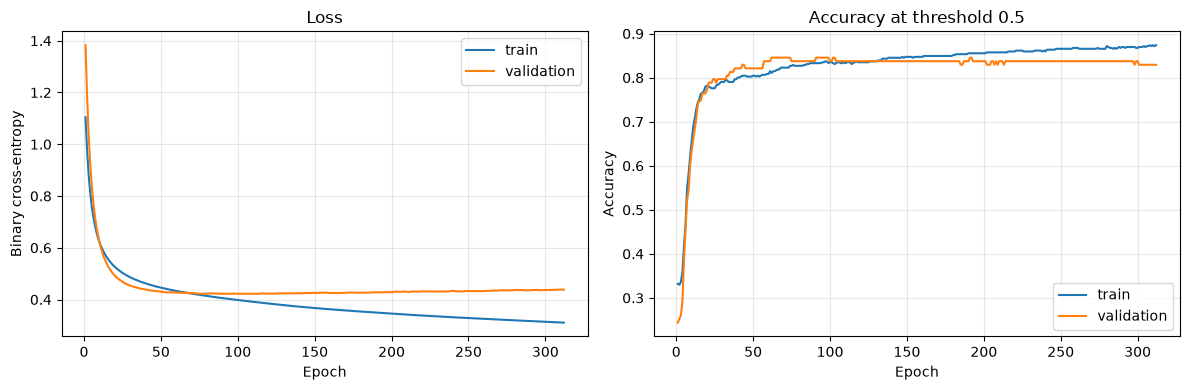

In [39]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 9. TRAINING
# # ============================================================
# 
# learning_rate = 0.01
# epochs = 1000
# 
# for epoch in range(epochs):
#     # Forward
#     y_hat, cache = forward(
#         X_train
#     )
# 
#     # Loss
#     loss = binary_cross_entropy(
#         y_train,
#         y_hat
#     )
# 
#     # Backward
#     gradients = backward(
#         y_train,
#         cache
#     )
# 
#     # Update
#     W1 -= (
#         learning_rate
#         * gradients["dW1"]
#     )
#     b1 -= (
#         learning_rate
#         * gradients["db1"]
#     )
# 
#     W2 -= (
#         learning_rate
#         * gradients["dW2"]
#     )
#     b2 -= (
#         learning_rate
#         * gradients["db2"]
#     )
# 
#     W3 -= (
#         learning_rate
#         * gradients["dW3"]
#     )
#     b3 -= (
#         learning_rate
#         * gradients["db3"]
#     )
# 
#     if epoch % 100 == 0:
#         print(
#             f"Epoch {epoch:4d} | "
#             f"Loss = {loss:.4f}"
#         )
# --- IMPROVED CODE ---

def make_class_weights(y):
    positive_count = float(np.sum(y == 1))
    negative_count = float(np.sum(y == 0))
    total = positive_count + negative_count

    positive_weight = total / (2.0 * max(positive_count, 1.0))
    negative_weight = total / (2.0 * max(negative_count, 1.0))

    weights = np.where(y == 1, positive_weight, negative_weight)
    return weights / np.mean(weights)


def accuracy_from_probabilities(y, y_hat, threshold=0.5):
    y_pred = (y_hat >= threshold).astype(int)
    return float(np.mean(y_pred == y))


learning_rate = 0.01
epochs = 3000
batch_size = 64
lambda_l2 = 0.001
patience = 200
min_delta = 1e-5

params = initialize_parameters(
    n_features=X_train.shape[1],
    hidden_1=32,
    hidden_2=16,
    seed=42,
)
train_weights = make_class_weights(y_train)

history = {
    "epoch": [],
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
}

rng = np.random.default_rng(42)
best_valid_loss = np.inf
best_epoch = 0
best_params = copy_parameters(params)
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    permutation = rng.permutation(len(X_train))

    for start in range(0, len(X_train), batch_size):
        batch_idx = permutation[start:start + batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        weight_batch = train_weights[batch_idx]

        y_hat_batch, cache = forward(X_batch, params)
        gradients = backward(
            y_batch,
            cache,
            params,
            sample_weights=weight_batch,
            lambda_l2=lambda_l2,
        )
        params = update_parameters(params, gradients, learning_rate)

    y_hat_train, _ = forward(X_train, params)
    y_hat_valid, _ = forward(X_valid, params)

    train_loss = compute_loss(
        y_train,
        y_hat_train,
        params,
        sample_weights=train_weights,
        lambda_l2=lambda_l2,
    )
    valid_loss = compute_loss(
        y_valid,
        y_hat_valid,
        params,
        lambda_l2=lambda_l2,
    )
    train_accuracy = accuracy_from_probabilities(y_train, y_hat_train, threshold=0.5)
    valid_accuracy = accuracy_from_probabilities(y_valid, y_hat_valid, threshold=0.5)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_accuracy"].append(valid_accuracy)

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_params = copy_parameters(params)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train_loss = {train_loss:.4f} | "
            f"valid_loss = {valid_loss:.4f} | "
            f"train_acc = {train_accuracy:.4f} | "
            f"valid_acc = {valid_accuracy:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break

params = copy_parameters(best_params)
print("Best validation loss:", best_valid_loss)
print("Best epoch:", best_epoch)

if plt is None:
    print("Matplotlib is not installed, so training plots are skipped.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["valid_loss"], label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_accuracy"], label="train")
    axes[1].plot(history["epoch"], history["valid_accuracy"], label="validation")
    axes[1].set_title("Accuracy at threshold 0.5")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    save_current_figure("diabetes_training_history.png")
    plt.show()


## 10. Prediction / Evaluation

Cell này đánh giá mô hình trên test set với threshold mặc định `0.5`, giống baseline. Output sigmoid là xác suất, còn threshold biến xác suất thành nhãn 0 hoặc 1.

Baseline tính accuracy, confusion matrix, precision, recall và F1 trong các cell riêng. Bản cải tiến gom các phép tính này vào hàm `calculate_metrics` để có thể tái sử dụng cho validation set, test set và nhiều threshold khác nhau.

Các chỉ số có ý nghĩa như sau:

- Accuracy: tỷ lệ dự đoán đúng tổng thể.
- Precision: trong các mẫu model dự đoán là diabetes, có bao nhiêu mẫu đúng.
- Recall: trong các mẫu thật sự diabetes, model tìm ra được bao nhiêu.
- F1: trung bình điều hòa giữa precision và recall.

Kết quả sau cell này:

- `y_prob_valid`: xác suất trên validation set.
- `y_prob_test`: xác suất trên test set.
- `test_metrics_050`: metrics trên test set với threshold `0.5`.

In [40]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 10. TEST
# # ============================================================
# 
# y_prob, _ = forward(
#     X_test
# )
# 
# y_pred = (
#     y_prob >= 0.5
# ).astype(int)# 
# # ============================================================
# # 11. ACCURACY
# # ============================================================
# 
# accuracy = np.mean(
#     y_pred == y_test
# )
# 
# print()
# print("==============================")
# print("TEST RESULTS")
# print("==============================")
# print("Accuracy:", accuracy)# 
# # ============================================================
# # 12. CONFUSION MATRIX
# # ============================================================
# 
# TP = np.sum(
#     (y_pred == 1)
#     &
#     (y_test == 1)
# )
# TN = np.sum(
#     (y_pred == 0)
#     &
#     (y_test == 0)
# )
# FP = np.sum(
#     (y_pred == 1)
#     &
#     (y_test == 0)
# )
# FN = np.sum(
#     (y_pred == 0)
#     &
#     (y_test == 1)
# )
# 
# print()
# print("Confusion Matrix")
# print("-----------------")
# print("TP:", TP)
# print("TN:", TN)
# print("FP:", FP)
# print("FN:", FN)# 
# # ============================================================
# # 13. PRECISION / RECALL / F1
# # ============================================================
# 
# precision = (
#     TP
#     /
#     (TP + FP + 1e-8)
# )
# recall = (
#     TP
#     /
#     (TP + FN + 1e-8)
# )
# f1 = (
#     2 * precision
#     * recall
#     /
#     (precision + recall + 1e-8)
# )
# 
# print()
# print("Precision:", precision)
# print("Recall   :", recall)
# print("F1       :", f1)
# --- IMPROVED CODE ---

def predict_probabilities(X, params):
    y_hat, _ = forward(X, params)
    return y_hat


def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    TP = np.sum(
        (y_pred == 1)
        &
        (y_true == 1)
    )
    TN = np.sum(
        (y_pred == 0)
        &
        (y_true == 0)
    )
    FP = np.sum(
        (y_pred == 1)
        &
        (y_true == 0)
    )
    FN = np.sum(
        (y_pred == 0)
        &
        (y_true == 1)
    )

    accuracy = np.mean(
        y_pred == y_true
    )
    precision = (
        TP
        /
        (TP + FP + 1e-8)
    )
    recall = (
        TP
        /
        (TP + FN + 1e-8)
    )
    f1 = (
        2 * precision
        * recall
        /
        (precision + recall + 1e-8)
    )

    return {
        "threshold": threshold,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
        "y_pred": y_pred,
    }


def print_metrics(title, metrics):
    print()
    print(title)
    print("=" * len(title))
    print("Threshold:", metrics["threshold"])
    print("Accuracy :", metrics["accuracy"])
    print("TP:", metrics["TP"])
    print("TN:", metrics["TN"])
    print("FP:", metrics["FP"])
    print("FN:", metrics["FN"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print("F1       :", metrics["f1"])


y_prob_valid = predict_probabilities(X_valid, params)
y_prob_test = predict_probabilities(X_test, params)

test_metrics_050 = calculate_metrics(y_test, y_prob_test, threshold=0.5)
print_metrics("TEST RESULTS AT THRESHOLD 0.5", test_metrics_050)


TEST RESULTS AT THRESHOLD 0.5
Threshold: 0.5
Accuracy : 0.8571428571428571
TP: 54
TN: 78
FP: 18
FN: 4
Precision: 0.7499999998958334
Recall   : 0.9310344825980975
F1       : 0.8307692256994085


## 11. Threshold Tuning

Cell này cải tiến bước chuyển xác suất thành nhãn. Baseline dùng threshold cố định `0.5`. Tuy nhiên với bài toán y tế và dữ liệu mất cân bằng, threshold `0.5` không phải lúc nào cũng cho cân bằng tốt giữa precision và recall.

Bản cải tiến thử nhiều threshold từ `0.10` đến `0.90` trên validation set, chọn threshold có F1 cao nhất, rồi chỉ sau đó mới áp dụng threshold này lên test set. Làm như vậy giúp tránh chọn threshold trực tiếp theo test set, vì test set nên được giữ cho đánh giá cuối cùng.

Kết quả sau cell này:

- `best_threshold`: threshold tốt nhất theo F1 trên validation set.
- `best_validation_metrics`: metrics validation tại threshold tốt nhất.
- `test_metrics_best_threshold`: metrics test khi dùng threshold đã chọn từ validation.

In [41]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 10. TEST
# # ============================================================
# 
# y_prob, _ = forward(
#     X_test
# )
# 
# y_pred = (
#     y_prob >= 0.5
# ).astype(int)
# --- IMPROVED CODE ---

thresholds = np.arange(0.10, 0.91, 0.01)
validation_metrics = [
    calculate_metrics(y_valid, y_prob_valid, threshold=float(threshold))
    for threshold in thresholds
]

best_validation_metrics = max(
    validation_metrics,
    key=lambda item: item["f1"]
)
best_threshold = best_validation_metrics["threshold"]

test_metrics_best_threshold = calculate_metrics(
    y_test,
    y_prob_test,
    threshold=best_threshold,
)

print_metrics("BEST VALIDATION THRESHOLD", best_validation_metrics)
print_metrics("TEST RESULTS AT BEST VALIDATION THRESHOLD", test_metrics_best_threshold)


BEST VALIDATION THRESHOLD
Threshold: 0.4699999999999998
Accuracy : 0.8455284552845529
TP: 28
TN: 76
FP: 13
FN: 6
Precision: 0.6829268291017252
Recall   : 0.8235294115224914
F1       : 0.7466666615111113

TEST RESULTS AT BEST VALIDATION THRESHOLD
Threshold: 0.4699999999999998
Accuracy : 0.8571428571428571
TP: 56
TN: 76
FP: 20
FN: 2
Precision: 0.7368421051662051
Recall   : 0.9655172412128419
F1       : 0.8358208904878593


## 11.1. Visualize Evaluation Results

Cell này biến các chỉ số đánh giá thành biểu đồ để dễ so sánh hơn. Thay vì chỉ nhìn các con số in ra, ta có thể thấy threshold ảnh hưởng thế nào đến precision, recall và F1.

Biểu đồ confusion matrix giúp quan sát trực tiếp model đang sai theo hướng nào: false positive hay false negative. Histogram xác suất dự đoán theo nhãn thật cho thấy hai lớp có được tách biệt rõ không. Nếu hai histogram chồng lên nhau nhiều, nghĩa là model còn khó phân biệt hai nhóm bệnh nhân.

Baseline chỉ in metrics dạng text, nên cell này là phần bổ sung để quan sát kết quả đánh giá.

Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes/report/figures/diabetes_evaluation_results.png


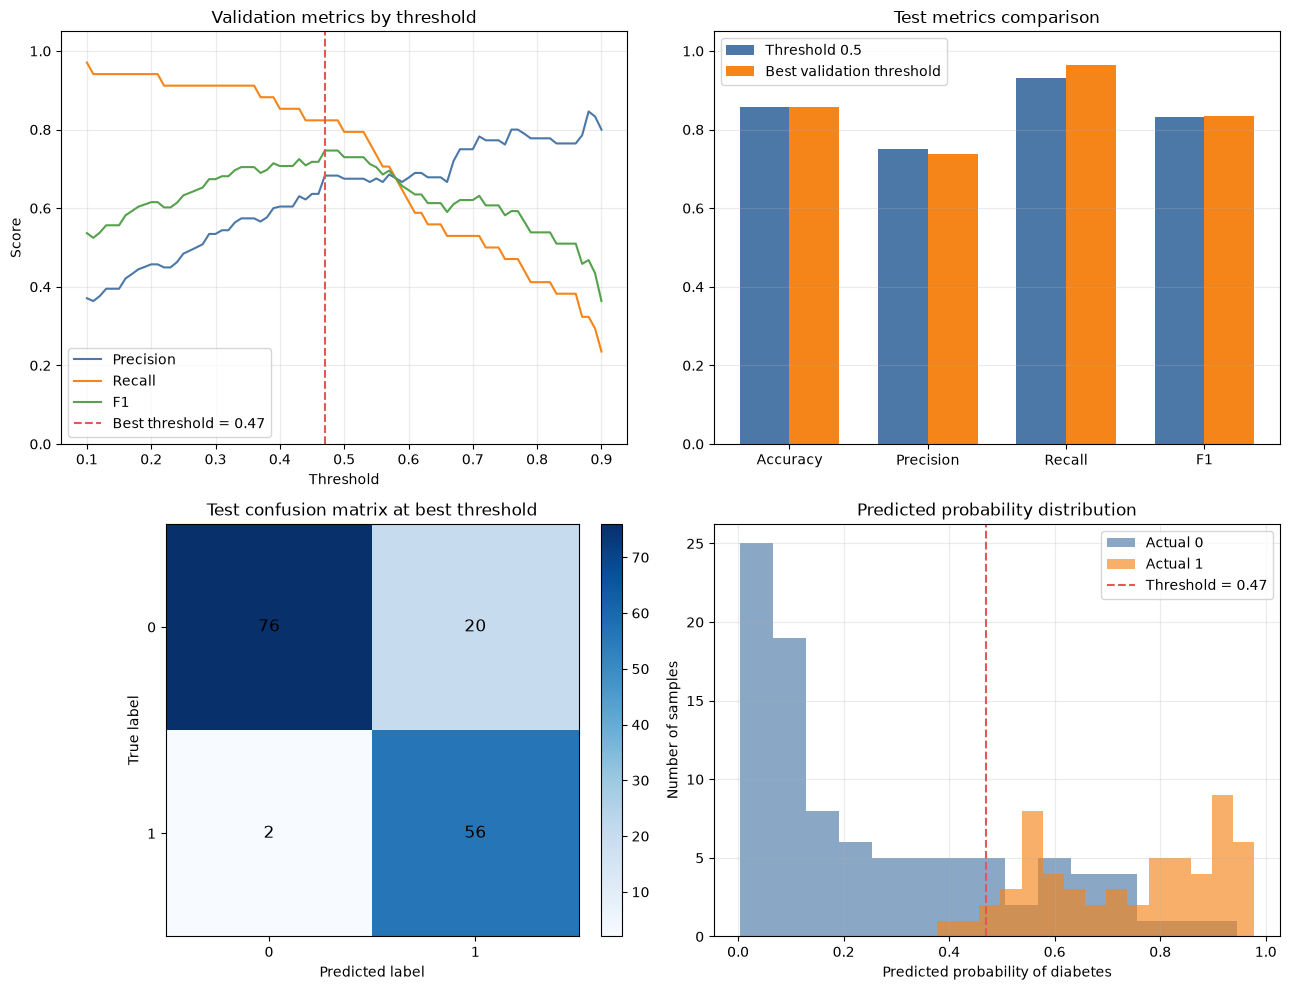

In [42]:
# --- BASELINE CODE (COMMENTED) ---
# Baseline notebook printed evaluation metrics but did not include evaluation charts.
# --- IMPROVED CODE ---

if plt is None:
    print("Matplotlib is not installed, so evaluation charts are skipped.")
else:
    threshold_values = np.array([item["threshold"] for item in validation_metrics])
    precision_values = np.array([item["precision"] for item in validation_metrics])
    recall_values = np.array([item["recall"] for item in validation_metrics])
    f1_values = np.array([item["f1"] for item in validation_metrics])

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0, 0].plot(threshold_values, precision_values, label="Precision", color="#4C78A8")
    axes[0, 0].plot(threshold_values, recall_values, label="Recall", color="#F58518")
    axes[0, 0].plot(threshold_values, f1_values, label="F1", color="#54A24B")
    axes[0, 0].axvline(
        best_threshold,
        color="#E45756",
        linestyle="--",
        label=f"Best threshold = {best_threshold:.2f}",
    )
    axes[0, 0].set_title("Validation metrics by threshold")
    axes[0, 0].set_xlabel("Threshold")
    axes[0, 0].set_ylabel("Score")
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].grid(True, alpha=0.25)
    axes[0, 0].legend()

    metric_names = ["accuracy", "precision", "recall", "f1"]
    metric_positions = np.arange(len(metric_names))
    metric_width = 0.36
    metrics_050 = [test_metrics_050[name] for name in metric_names]
    metrics_best = [test_metrics_best_threshold[name] for name in metric_names]

    axes[0, 1].bar(
        metric_positions - metric_width / 2,
        metrics_050,
        metric_width,
        label="Threshold 0.5",
        color="#4C78A8",
    )
    axes[0, 1].bar(
        metric_positions + metric_width / 2,
        metrics_best,
        metric_width,
        label="Best validation threshold",
        color="#F58518",
    )
    axes[0, 1].set_title("Test metrics comparison")
    axes[0, 1].set_xticks(metric_positions)
    axes[0, 1].set_xticklabels([name.capitalize() for name in metric_names])
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].grid(True, axis="y", alpha=0.25)
    axes[0, 1].legend()

    confusion_matrix = np.array([
        [test_metrics_best_threshold["TN"], test_metrics_best_threshold["FP"]],
        [test_metrics_best_threshold["FN"], test_metrics_best_threshold["TP"]],
    ])
    image = axes[1, 0].imshow(confusion_matrix, cmap="Blues")
    axes[1, 0].set_title("Test confusion matrix at best threshold")
    axes[1, 0].set_xlabel("Predicted label")
    axes[1, 0].set_ylabel("True label")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_yticks([0, 1])
    axes[1, 0].set_xticklabels(["0", "1"])
    axes[1, 0].set_yticklabels(["0", "1"])
    for row_idx in range(confusion_matrix.shape[0]):
        for col_idx in range(confusion_matrix.shape[1]):
            axes[1, 0].text(
                col_idx,
                row_idx,
                str(confusion_matrix[row_idx, col_idx]),
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )
    fig.colorbar(image, ax=axes[1, 0], fraction=0.046, pad=0.04)

    probabilities_no_diabetes = y_prob_test[y_test.ravel() == 0].ravel()
    probabilities_diabetes = y_prob_test[y_test.ravel() == 1].ravel()
    axes[1, 1].hist(
        probabilities_no_diabetes,
        bins=15,
        alpha=0.65,
        label="Actual 0",
        color="#4C78A8",
    )
    axes[1, 1].hist(
        probabilities_diabetes,
        bins=15,
        alpha=0.65,
        label="Actual 1",
        color="#F58518",
    )
    axes[1, 1].axvline(
        best_threshold,
        color="#E45756",
        linestyle="--",
        label=f"Threshold = {best_threshold:.2f}",
    )
    axes[1, 1].set_title("Predicted probability distribution")
    axes[1, 1].set_xlabel("Predicted probability of diabetes")
    axes[1, 1].set_ylabel("Number of samples")
    axes[1, 1].grid(True, alpha=0.25)
    axes[1, 1].legend()

    plt.tight_layout()
    save_current_figure("diabetes_evaluation_results.png")
    plt.show()


## 12. Example Predictions

Cell cuối cùng in một số dự đoán mẫu để kiểm tra trực quan output của model. Mỗi dòng gồm xác suất dự đoán, nhãn dự đoán sau threshold và nhãn thật.

Baseline cũng in 10 dự đoán đầu tiên trên test set. Bản cải tiến giữ cùng cách trình bày nhưng dùng `best_threshold` đã chọn từ validation thay vì threshold cố định `0.5`.

Phần này không dùng để đánh giá chính thức, nhưng giúp đọc kết quả dễ hơn: ta thấy được model tự tin ở mức nào với từng bệnh nhân, và có thể so sánh xác suất với nhãn thật.

Kết quả sau cell này là danh sách tối đa 10 dòng dự đoán mẫu từ test set.

In [43]:
# --- BASELINE CODE (COMMENTED) ---
# # ============================================================
# # 14. EXAMPLE PREDICTIONS
# # ============================================================
# 
# print()
# print("Example predictions")
# print("--------------------")
# 
# for i in range(
#     min(10, len(X_test))
# ):
#     print(
#         f"Patient {i + 1:2d} | "
#         f"Probability = "
#         f"{y_prob[i, 0]:.3f} | "
#         f"Prediction = "
#         f"{y_pred[i, 0]} | "
#         f"Actual = "
#         f"{int(y_test[i, 0])}"
#     )
# --- IMPROVED CODE ---

print()
print("Example predictions")
print("--------------------")

final_y_pred = test_metrics_best_threshold["y_pred"]

for i in range(
    min(10, len(X_test))
):
    print(
        f"Patient {i + 1:2d} | "
        f"Probability = "
        f"{y_prob_test[i, 0]:.3f} | "
        f"Prediction = "
        f"{final_y_pred[i, 0]} | "
        f"Actual = "
        f"{int(y_test[i, 0])}"
    )


Example predictions
--------------------
Patient  1 | Probability = 0.051 | Prediction = 0 | Actual = 0
Patient  2 | Probability = 0.225 | Prediction = 0 | Actual = 0
Patient  3 | Probability = 0.735 | Prediction = 1 | Actual = 0
Patient  4 | Probability = 0.577 | Prediction = 1 | Actual = 0
Patient  5 | Probability = 0.817 | Prediction = 1 | Actual = 1
Patient  6 | Probability = 0.513 | Prediction = 1 | Actual = 0
Patient  7 | Probability = 0.315 | Prediction = 0 | Actual = 0
Patient  8 | Probability = 0.196 | Prediction = 0 | Actual = 0
Patient  9 | Probability = 0.544 | Prediction = 1 | Actual = 1
Patient 10 | Probability = 0.319 | Prediction = 0 | Actual = 0
